In [1]:
!pip install mediapipe==0.10.9 --quiet
!pip install opencv-python-headless==4.8.0.76 --quiet
!pip install numpy matplotlib imutils --quiet

!pip uninstall -y mediapipe mediapipe-silicon tensorflow tensorflow-intel
!pip install mediapipe==0.10.5 --quiet

# Compatible numpy + scipy for mediapipe
!pip install numpy==1.26.4 scipy==1.10.1 --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 17.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 53.9 MB/s eta 0:00:0000:0100:01m
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.


In [2]:
import cv2, os, math
import numpy as np
import mediapipe as mp
from matplotlib import pyplot as plt
from imutils import rotate_bound

mp_face_mesh = mp.solutions.face_mesh

LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

In [3]:
def euclidean(p1, p2):
    return np.linalg.norm(p1 - p2)

def eye_aspect_ratio(eye):
    A = euclidean(eye[1], eye[5])
    B = euclidean(eye[2], eye[4])
    C = euclidean(eye[0], eye[3])
    return (A + B) / (2.0 * C)

def get_face_angle(landmarks, img):
    left = np.array([landmarks[33].x * img.shape[1], landmarks[33].y * img.shape[0]])
    right = np.array([landmarks[263].x * img.shape[1], landmarks[263].y * img.shape[0]])
    dx, dy = right - left
    return math.degrees(math.atan2(dy, dx))


In [4]:
def compute_EAR_and_draw(image):
    with mp_face_mesh.FaceMesh(static_image_mode=True, refine_landmarks=True) as mesh:
        
        # 1st pass
        results = mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks:
            return None, None
        
        landmarks = results.multi_face_landmarks[0].landmark
        angle = get_face_angle(landmarks, image)

        aligned = rotate_bound(image, -angle)
        
        # 2nd pass (after alignment)
        results = mesh.process(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks:
            return None, None
        
        lm = results.multi_face_landmarks[0].landmark
        
        def extract_eye(idx):
            return np.array([[lm[i].x * aligned.shape[1], lm[i].y * aligned.shape[0]] for i in idx])
        
        left = extract_eye(LEFT_EYE)
        right = extract_eye(RIGHT_EYE)
        ear = (eye_aspect_ratio(left) + eye_aspect_ratio(right)) / 2
        
        # Draw
        vis = aligned.copy()
        for eye in [LEFT_EYE, RIGHT_EYE]:
            for idx in eye:
                x = int(lm[idx].x * aligned.shape[1])
                y = int(lm[idx].y * aligned.shape[0])
                cv2.circle(vis, (x,y), 2, (0,255,0), -1)
        
        cv2.putText(vis, f"EAR: {ear:.3f}", (10,30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

        return ear, vis


In [5]:
data_dir = "/kaggle/input/baby-postures/test"

ears = []
images = []
titles = []

for img_name in os.listdir(data_dir):
    path = f"{data_dir}/{img_name}"
    img = cv2.imread(path)
    if img is None: 
        continue

    ear, output = compute_EAR_and_draw(img)
    
    if ear is not None:
        ears.append(ear)
        images.append(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        titles.append(f"{ear:.3f}")

print(f"✅ EAR extracted for {len(ears)} images")
print("Mean EAR:", np.mean(ears))
print("Std:", np.std(ears))


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


✅ EAR extracted for 7 images
Mean EAR: 0.1729837063797784
Std: 0.09519813362711062


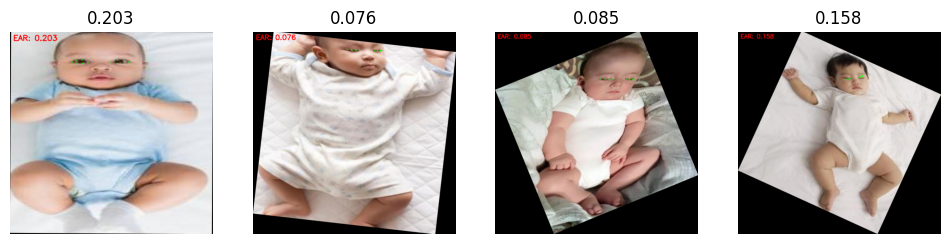

In [6]:
cols = 4
rows = min(3, len(images)//cols)

plt.figure(figsize=(12, 8))
for i in range(rows * cols):
    plt.subplot(rows, cols, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.show()


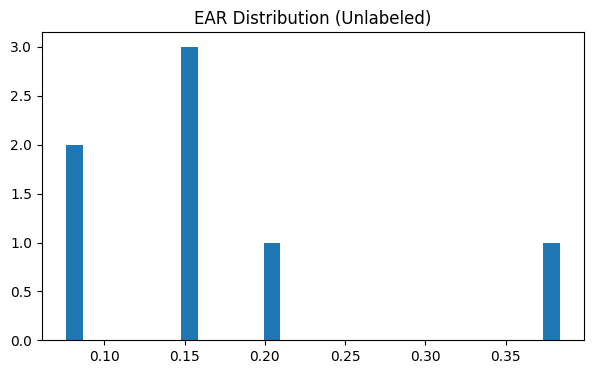

Suggested sleep threshold = 0.1253846395662231


In [7]:
plt.figure(figsize=(7,4))
plt.hist(ears, bins=30)
plt.title("EAR Distribution (Unlabeled)")
plt.show()

thr = np.mean(ears) - 0.5*np.std(ears)
print("Suggested sleep threshold =", thr)
